# Comparative Emotion Classification in Short User-Generated Text

### CM3060 Natural Language Processing<br/> Name: Jaslyn Chan Yu Xin<br/> Student ID: 240662387

The project compares a traditional statistical text classifier with an embedding-based neural model for emotion classification in short user-generated text. It uses Google Research's GoEmotions dataset and filters the original labels to six target classes: `joy`, `anger`, `fear`, `sadness`, `surprise`, and `neutral`.

## 1. Setup

Run the install cell if the required libraries are missing. If your environment already has these packages, you can skip it.

In [1]:
# Optional install cell. Uncomment and run if needed.
# %pip install -q pandas numpy scikit-learn matplotlib seaborn datasets tensorflow

In [2]:
# Core data handling and plotting
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset  # GoEmotions loader

# Statistical models (baseline, Naive Bayes, Logistic Regression) and evaluation
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Embedding-based neural model
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Fix random seeds so results are reproducible across runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 2. Load and Filter GoEmotions

GoEmotions contains 27 fine-grained emotion categories plus neutral. To keep the classification task focused, this project filters the dataset to six existing labels only. The comments are not manually relabelled.

In [3]:
# Download GoEmotions (already split into train/validation/test by the dataset authors)
raw_dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [4]:
# Map our 6 target emotion names to their IDs in the original 28-class scheme,
# and build a lookup to compress those IDs down to a compact 0-5 range.
label_names = raw_dataset["train"].features["labels"].feature.names
target_label_names = ["joy", "anger", "fear", "sadness", "surprise", "neutral"]
target_label_ids = [label_names.index(label) for label in target_label_names]
target_id_to_new_id = {old_id: new_id for new_id, old_id in enumerate(target_label_ids)}

print("Original label count:", len(label_names))
print("Target labels:", target_label_names)
print("Target label IDs:", target_label_ids)

Original label count: 28
Target labels: ['joy', 'anger', 'fear', 'sadness', 'surprise', 'neutral']
Target label IDs: [17, 2, 14, 25, 26, 27]


In [5]:
# Keep only comments with exactly one label, and that label must be one of our six targets.
# Comments with multiple labels or with an excluded emotion are dropped, not relabelled.
def keep_single_target_label(example):
    labels = example["labels"]
    return len(labels) == 1 and labels[0] in target_label_ids


# Rewrite the kept comments to use the compact 0-5 label space defined above.
def convert_to_six_class_label(example):
    old_label_id = example["labels"][0]
    new_label_id = target_id_to_new_id[old_label_id]
    return {
        "text": example["text"],
        "label": new_label_id,
        "label_name": target_label_names[new_label_id],
    }


dataset_filtered = raw_dataset.filter(keep_single_target_label)
dataset_filtered = dataset_filtered.map(
    convert_to_six_class_label,
    remove_columns=raw_dataset["train"].column_names,
)

dataset_filtered

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 16668
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 2044
    })
    test: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 2084
    })
})

In [6]:
# Convert to pandas for easier downstream use with sklearn/Keras.
# These splits come pre-divided from GoEmotions itself; no manual splitting is done here.
train_df = dataset_filtered["train"].to_pandas()
val_df = dataset_filtered["validation"].to_pandas()
test_df = dataset_filtered["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (16668, 3)
Validation: (2044, 3)
Test: (2084, 3)


,text,label,label_name
0,My favourite food is anything I didn't have to...,5,neutral
1,"Now if he does off himself, everyone will thin...",5,neutral
2,WHY THE FUCK IS BAYLESS ISOING,1,anger
3,To make her feel threatened,2,fear
4,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,4,surprise


## 3. Exploratory Data Analysis

The class distribution matters because imbalanced classes can make accuracy misleading. Per-class F1-score and confusion matrices are therefore included later.

label_name
joy           853
anger        1025
fear          430
sadness       817
surprise      720
neutral     12823
Name: count, dtype: int64

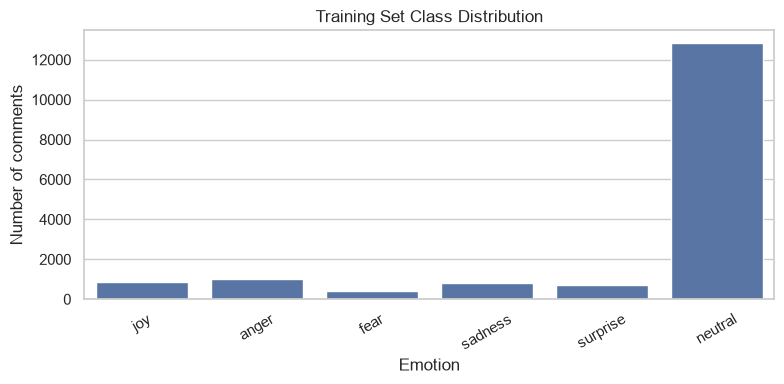

In [7]:
class_counts = train_df["label_name"].value_counts().reindex(target_label_names)
display(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Training Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of comments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Reading this chart:** `neutral` makes up about 77% of the training data (12,823 of 16,668 comments), while the other five emotions share the rest. This is a real class imbalance, not a charting artefact: a model that simply guesses "neutral" every time would already score ~77% accuracy without learning anything (see the baseline model in Section 6). This is why **macro F1** is reported alongside accuracy throughout this notebook: it scores all six classes equally, rather than letting the large `neutral` class dominate the result.

In [8]:
# Sanity-check the labels by reading one random example per class.
for label in target_label_names:
    sample = train_df[train_df["label_name"] == label].sample(1, random_state=RANDOM_STATE)
    print(f"\n[{label}]")
    print(sample["text"].iloc[0])


[joy]
I switched to Ally and love it. 2.2% interest is awesome

[anger]
[NAME] what the hell is going on at hq

[fear]
My darling, have you bowed down to worship the ancient one yet? We are very worried. 

[sadness]
I’ll miss you, [NAME] Today is a sad day for our high sock loving brethren [NAME]

[surprise]
I wasn’t even expecting the reply that’s why I’m literally bamboozled.

[neutral]
If [NAME] gave me pizza I'd still be annoyed but I'd eat it.


## 4. Preprocessing

For the statistical models, preprocessing is handled inside scikit-learn vectorizers. TF-IDF and bag-of-words represent text using token frequency patterns.

For the embedding model, text is tokenized into integer sequences and padded to a fixed length so that it can be passed into a neural network embedding layer.

Lemmatization is intentionally skipped: GoEmotions comments are short, informal Reddit text where inflectional variants of the same word rarely co-occur within a single comment, so the added complexity is unlikely to change classification outcomes. Stop-word removal and a minimum document frequency are used instead to reduce noise from very common or very rare tokens (rationale given next to each vectorizer below).

In [9]:
# Separate text (features) and label (target) for each split.
X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(int)

X_val = val_df["text"].astype(str)
y_val = val_df["label"].astype(int)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(int)

num_classes = len(target_label_names)

## 5. Evaluation Helper

**Why both macro F1 and weighted F1 are reported:**
- **Macro F1** averages the F1-score of each class equally, regardless of how many examples it has. This is the fairer metric given the heavy `neutral` imbalance shown above, since it answers "how well does the model do across all six emotions, including the rare ones?"
- **Weighted F1** averages F1-scores weighted by how many examples each class has, so it is dominated by the large `neutral` class. It answers "how well does the model do on a typical test example?"
- **Accuracy** alone is the least reliable metric here, since a model that always predicts `neutral` already scores ~77% (see Section 6) without learning anything.

In [10]:
# Score a model on accuracy/macro F1/weighted F1, print a classification report,
# plot a confusion matrix, and record the scores for the final comparison table.
results = []


def evaluate_model(model_name, y_true, y_pred, results_list=None):
    if results_list is None:
        results_list = results

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    results_list.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

    print(f"{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=target_label_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_label_names,
        yticklabels=target_label_names,
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 6. Baseline Model

The baseline predicts the most frequent class in the training data. This gives a minimum benchmark that useful models should beat.

Majority-Class Baseline
-----------------------
Accuracy: 0.7706
Macro F1: 0.1451
Weighted F1: 0.6708

              precision    recall  f1-score   support

         joy       0.00      0.00      0.00        93
       anger       0.00      0.00      0.00       131
        fear       0.00      0.00      0.00        65
     sadness       0.00      0.00      0.00       102
    surprise       0.00      0.00      0.00        87
     neutral       0.77      1.00      0.87      1606

    accuracy                           0.77      2084
   macro avg       0.13      0.17      0.15      2084
weighted avg       0.59      0.77      0.67      2084



C:\Users\Admin\Documents\mods\NLP\nlp-emotion-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\Documents\mods\NLP\nlp-emotion-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\Documents\mods\NLP\nlp-emotion-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

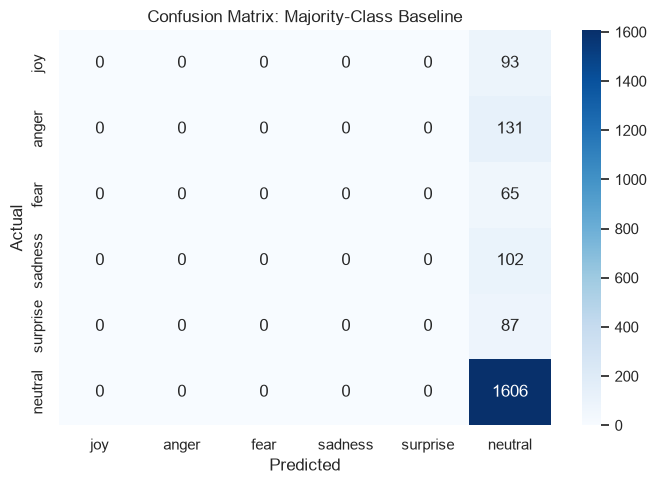

In [11]:
# Always predicts the majority class (neutral); the minimum bar a useful model must beat.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

evaluate_model("Majority-Class Baseline", y_test, baseline_pred)

## 7. Statistical Models

The first statistical model uses bag-of-words with Multinomial Naive Bayes, matching the course topic on Bayesian text classification. The second uses TF-IDF with Logistic Regression as a stronger traditional baseline.

**How bag-of-words + Naive Bayes works:** `CountVectorizer` represents each comment as a vector of raw word counts (word order is ignored, so "not happy" and "happy not" look the same). `MultinomialNB` then uses Bayes' theorem to estimate, for each class, how likely that combination of word counts is, and picks the most probable class. It is fast and a reasonable first attempt, but because it does not weight words by how distinctive they are, it tends to lean toward whichever class is most common in training (here, `neutral`) whenever the wording is ambiguous.

Bag-of-Words + Multinomial Naive Bayes
--------------------------------------
Accuracy: 0.8028
Macro F1: 0.4065
Weighted F1: 0.7542

              precision    recall  f1-score   support

         joy       0.79      0.33      0.47        93
       anger       0.62      0.18      0.27       131
        fear       0.91      0.15      0.26        65
     sadness       0.77      0.23      0.35       102
    surprise       0.71      0.11      0.20        87
     neutral       0.81      0.98      0.89      1606

    accuracy                           0.80      2084
   macro avg       0.77      0.33      0.41      2084
weighted avg       0.79      0.80      0.75      2084



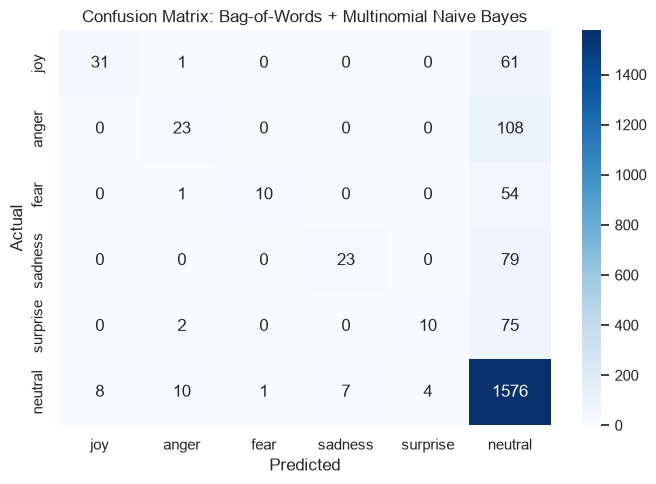

In [12]:
# stop_words="english" removes common function words that carry little emotional signal.
# min_df=2 drops tokens that appear in only one training comment, which are usually
# typos or rare usernames/slang that would otherwise add noise without generalizing.
nb_model = Pipeline([
    ("vectorizer", CountVectorizer(lowercase=True, stop_words="english", min_df=2)),
    ("classifier", MultinomialNB()),
])

nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

evaluate_model("Bag-of-Words + Multinomial Naive Bayes", y_test, nb_pred)

**What TF-IDF measures:** Term Frequency-Inverse Document Frequency weights each word by how often it appears in a given comment (term frequency) multiplied by how rare it is across all comments (inverse document frequency). Common words like "the" get a low weight everywhere; distinctive words like "furious" get a high weight wherever they appear. This gives the classifier below a cleaner signal than the raw word counts used above. Combined with `class_weight="balanced"` (see code comment below), this is why the TF-IDF + Logistic Regression model detects minority emotions noticeably better than the Naive Bayes model above.

TF-IDF + Logistic Regression
----------------------------
Accuracy: 0.8013
Macro F1: 0.6455
Weighted F1: 0.8116

              precision    recall  f1-score   support

         joy       0.61      0.80      0.69        93
       anger       0.47      0.61      0.53       131
        fear       0.64      0.75      0.69        65
     sadness       0.51      0.69      0.59       102
    surprise       0.43      0.59      0.50        87
     neutral       0.92      0.84      0.88      1606

    accuracy                           0.80      2084
   macro avg       0.60      0.71      0.65      2084
weighted avg       0.83      0.80      0.81      2084



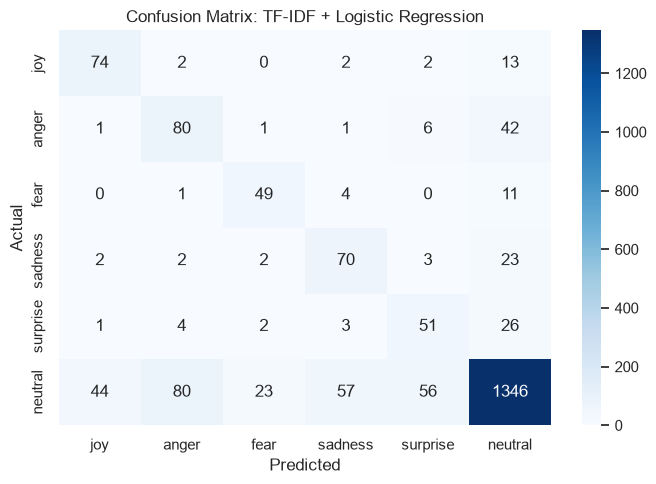

In [13]:
# Same stop-word and min_df rationale as the Naive Bayes model above.
# ngram_range=(1, 2) additionally captures short emotional phrases (e.g. "not happy")
# that single tokens alone would miss; class_weight="balanced" compensates for the
# class imbalance shown in the EDA section.
tfidf_lr_model = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=True, stop_words="english", min_df=2, ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

tfidf_lr_model.fit(X_train, y_train)
tfidf_lr_pred = tfidf_lr_model.predict(X_test)

evaluate_model("TF-IDF + Logistic Regression", y_test, tfidf_lr_pred)

## 8. Embedding-Based Neural Model

This model learns a task-specific embedding for words in the filtered GoEmotions data. The architecture is intentionally simple so that the comparison focuses on representation and classification approach rather than excessive model complexity.

**How tokenizing and padding work:** Neural networks need fixed-size numeric input, not raw sentences. `Tokenizer` builds a word→integer dictionary from the training text (the most frequent `max_words` words; anything rarer is mapped to a shared `<OOV>` "unknown word" token). Each comment then becomes a list of integers, one per word. `pad_sequences` forces every list to the same length (`max_len`) by adding zeros to short comments and cutting off long ones, so every comment can be fed into the network as a same-shaped array.

In [14]:
# max_words=12000 covers the overwhelming majority of distinct tokens in the training
# vocabulary while keeping the embedding matrix small; rarer tokens map to <OOV>.
# max_len=40 comfortably covers most GoEmotions comments, which are short
# (typically well under 40 tokens), so truncation affects very few examples.
# embedding_dim=64 is a small, standard size for a coursework-scale neural network;
# it is large enough to capture useful word relationships without overfitting
# on a dataset of this size.
max_words = 12000
max_len = 40
embedding_dim = 64

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post", truncating="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding="post", truncating="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding="post", truncating="post")

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

**What each layer of the network does:**
- `Embedding`: a lookup table that turns each word's integer ID into a 64-number vector. Unlike TF-IDF's fixed weights, these numbers are *learned* during training, so words used in similar emotional contexts can end up with similar vectors.
- `GlobalAveragePooling1D`: averages a comment's word vectors into one single vector, so comments of different lengths all end up the same size.
- `Dropout(0.3)`: randomly ignores 30% of values during training only, to stop the network from memorising the training data too closely.
- `Dense(64, relu)`: a hidden layer that lets the network combine word-vector features in non-linear ways.
- `Dense(6, softmax)`: the output layer, which turns the network's internal representation into a probability for each of the six emotions, summing to 1.

In [15]:
# Architecture rationale is explained in the markdown cell above.
embedding_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

embedding_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Build with the known input shape so summary() reports real output shapes/param counts
# instead of "unbuilt" placeholders (the model would otherwise only build on first use).
embedding_model.build(input_shape=(None, max_len))
embedding_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,550 (2.95 MB)

 Trainable params: 772,550 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Stop training once validation loss stops improving for 2 epochs, and restore the best
# weights seen so far (guards against overfitting past the point where the model peaks).
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = embedding_model.fit(
    X_train_seq,
    y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10


  1/261 ━━━━━━━━━━━━━━━━━━━━ 1:25 329ms/step - accuracy: 0.0469 - loss: 1.8138

 50/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6956 - loss: 1.4163    

101/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7236 - loss: 1.2763

152/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7344 - loss: 1.2076

...

 97/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8939 - loss: 0.3479

146/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8937 - loss: 0.3475

197/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8939 - loss: 0.3472

248/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8944 - loss: 0.3464

261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8981 - loss: 0.3384 - val_accuracy: 0.8439 - val_loss: 0.5999


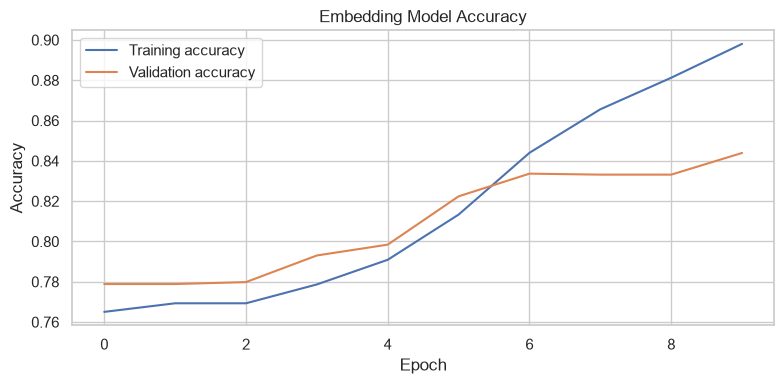

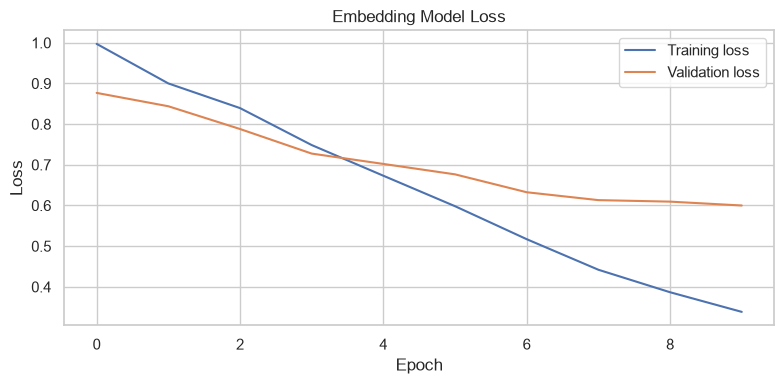

In [17]:
# Diagnostic plots: a widening gap between training and validation curves indicates overfitting.
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Embedding Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Embedding Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

 1/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step


Keras Embedding Neural Network
------------------------------
Accuracy: 0.8464
Macro F1: 0.5926
Weighted F1: 0.8303

              precision    recall  f1-score   support

         joy       0.76      0.68      0.72        93
       anger       0.58      0.40      0.47       131
        fear       0.90      0.29      0.44        65
     sadness       0.70      0.50      0.58       102
    surprise       0.55      0.34      0.42        87
     neutral       0.88      0.96      0.92      1606

    accuracy                           0.85      2084
   macro avg       0.73      0.53      0.59      2084
weighted avg       0.83      0.85      0.83      2084



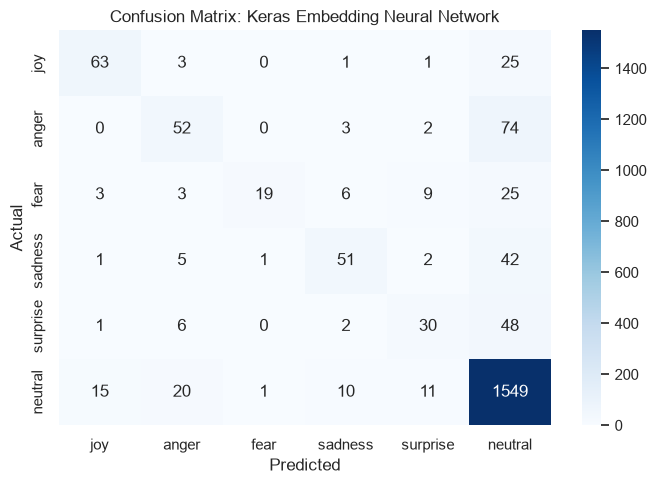

In [18]:
# Convert predicted probabilities to a single class per comment (highest probability wins).
embedding_probs = embedding_model.predict(X_test_seq)
embedding_pred = embedding_probs.argmax(axis=1)

evaluate_model("Keras Embedding Neural Network", y_test, embedding_pred)

## 8b. Ablation: Does Class Weighting Help the Embedding Model?

The TF-IDF + Logistic Regression model above uses `class_weight="balanced"` to counter the heavy `neutral` imbalance, and it scores higher on macro F1 than the embedding model even though the embedding model scores higher on accuracy. This raises a natural question: is the embedding model's weaker macro F1 simply caused by the *absence* of that same correction?

Rather than assume the answer, this section tests it directly: an identical embedding architecture is retrained from scratch with per-class weights computed using the same "balanced" formula scikit-learn uses internally, and the result is compared against the unweighted model above.

In [19]:
# weight_c = n_samples / (n_classes * count_c) -- the same formula scikit-learn applies
# internally for class_weight="balanced", reused here for a like-for-like comparison.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train,
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {target_label_names[i]: round(w, 2) for i, w in class_weight_dict.items()})

# Same architecture as the unweighted model in Section 8, trained from scratch so the
# comparison isolates the effect of class weighting rather than continuing training.
embedding_model_weighted = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

embedding_model_weighted.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping_ablation = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

ablation_history = embedding_model_weighted.fit(
    X_train_seq,
    y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_ablation],
    verbose=1,
)

Class weights: {'joy': np.float64(3.26), 'anger': np.float64(2.71), 'fear': np.float64(6.46), 'sadness': np.float64(3.4), 'surprise': np.float64(3.86), 'neutral': np.float64(0.22)}
Epoch 1/10


  1/261 ━━━━━━━━━━━━━━━━━━━━ 1:29 343ms/step - accuracy: 0.1562 - loss: 1.4775

 51/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3967 - loss: 1.6959    

101/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3607 - loss: 1.7568

150/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3118 - loss: 1.7812

...

102/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8169 - loss: 0.3366

154/261 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.8147 - loss: 0.3407

204/261 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.8125 - loss: 0.3448

255/261 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.8113 - loss: 0.3466

261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8096 - loss: 0.3499 - val_accuracy: 0.7945 - val_loss: 0.6751


 1/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step


Keras Embedding NN (Class-Weighted)
-----------------------------------
Accuracy: 0.8124
Macro F1: 0.6274
Weighted F1: 0.8171

              precision    recall  f1-score   support

         joy       0.44      0.81      0.57        93
       anger       0.62      0.53      0.58       131
        fear       0.65      0.69      0.67        65
     sadness       0.75      0.52      0.61       102
    surprise       0.41      0.49      0.45        87
     neutral       0.90      0.88      0.89      1606

    accuracy                           0.81      2084
   macro avg       0.63      0.65      0.63      2084
weighted avg       0.83      0.81      0.82      2084



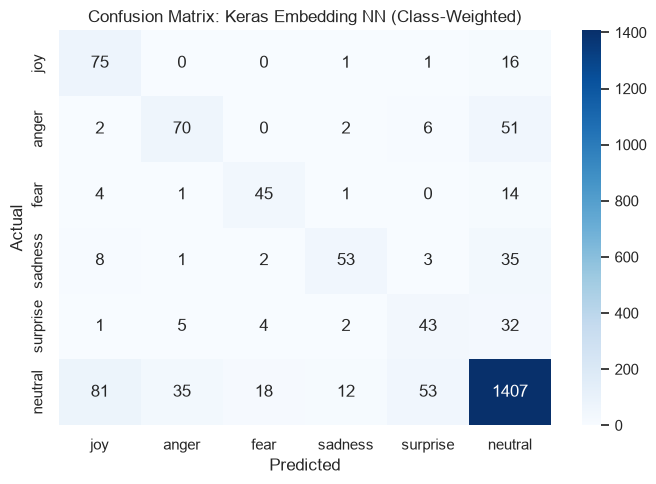

In [20]:
# Evaluate into a separate results list so this ablation doesn't get mixed into the
# headline model comparison in Section 9.
ablation_results = []

embedding_weighted_probs = embedding_model_weighted.predict(X_test_seq)
embedding_weighted_pred = embedding_weighted_probs.argmax(axis=1)

evaluate_model(
    "Keras Embedding NN (Class-Weighted)",
    y_test,
    embedding_weighted_pred,
    results_list=ablation_results,
)

,model,accuracy,macro_f1,weighted_f1
0,Keras Embedding Neural Network,0.846449,0.592575,0.830256
1,Keras Embedding NN (Class-Weighted),0.812380,0.627415,0.817148


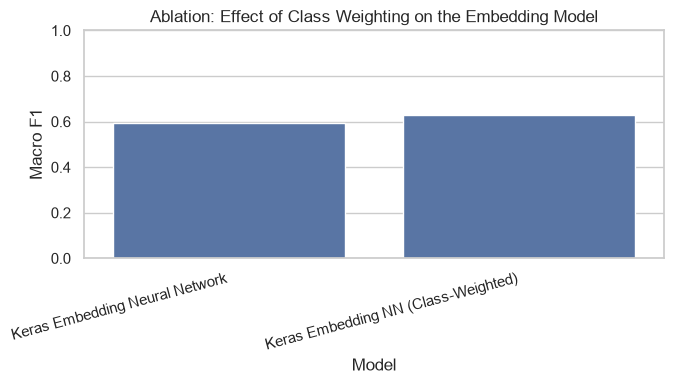

In [21]:
# Compare the unweighted embedding model (Section 8) against this class-weighted variant.
embedding_unweighted_row = next(r for r in results if r["model"] == "Keras Embedding Neural Network")
ablation_comparison_df = pd.DataFrame([embedding_unweighted_row, *ablation_results])
display(ablation_comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=ablation_comparison_df, x="model", y="macro_f1")
plt.title("Ablation: Effect of Class Weighting on the Embedding Model")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Finding:** Class weighting noticeably helps the embedding model: macro F1 improves from 0.593 (unweighted) to 0.627 (weighted), driven by large recall gains on minority classes (`fear` 0.29 → 0.69, `surprise` 0.34 → 0.49, `anger` 0.40 → 0.53), at the cost of some `neutral` precision/recall. This closes most, though not all, of the gap to TF-IDF + Logistic Regression's macro F1 of 0.645 — the statistical model with explicit balancing is still the strongest model on this metric, but the embedding model becomes competitive once trained on equal footing.

**A caveat worth flagging directly:** re-running this exact cell (same architecture, same `RANDOM_STATE=42`) produced a different result in an earlier run of this notebook — macro F1 of 0.557, i.e. *worse* than the unweighted model, with unstable validation accuracy across epochs. The seeds set in Section 1 (`numpy`, `random`, `tf.random.set_seed`) do not fully guarantee determinism for this model: TensorFlow's oneDNN-accelerated CPU ops are explicitly documented to reorder floating-point operations between runs, producing different numerical results even with fixed seeds. In practice, this means a single run of the class-weighted embedding model is not fully reliable evidence on its own — the qualitative direction (weighting improves minority-class recall) is consistent across runs, but the exact macro F1 value, and whether it overtakes TF-IDF + Logistic Regression, is not. A more rigorous treatment would average results over several runs; this is noted here as a reproducibility limitation rather than resolved, consistent with the project's preference for transparency over an artificially clean conclusion.

## 9. Model Comparison

,model,accuracy,macro_f1,weighted_f1
2,TF-IDF + Logistic Regression,0.801344,0.645485,0.811620
3,Keras Embedding Neural Network,0.846449,0.592575,0.830256
1,Bag-of-Words + Multinomial Naive Bayes,0.802783,0.406469,0.754208
0,Majority-Class Baseline,0.770633,0.145077,0.670806


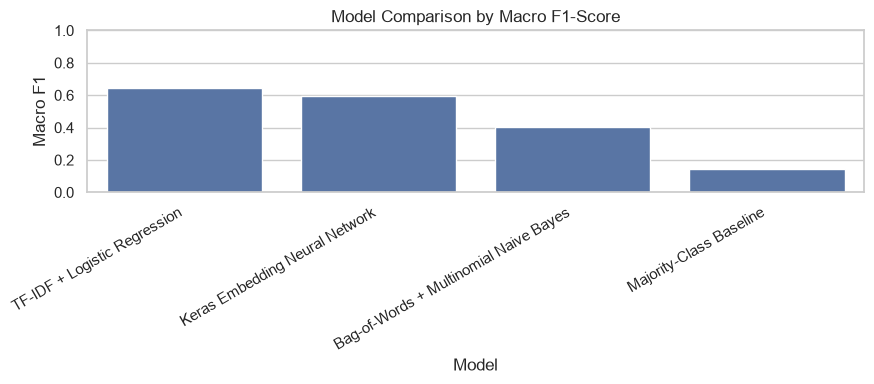

In [22]:
# Rank all models by macro F1, the fairest metric given the class imbalance discussed earlier.
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df)

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="model", y="macro_f1")
plt.title("Model Comparison by Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Error Analysis

Reviewing misclassified examples helps explain why some emotions are harder to identify. This is useful for the coursework discussion section.

In [23]:
# Inspect misclassified examples from the strongest traditional model (TF-IDF + Logistic
# Regression) to understand which kinds of comments are hardest to classify.
analysis_df = test_df.copy()
analysis_df["predicted_label"] = [target_label_names[i] for i in tfidf_lr_pred]
analysis_df["true_label"] = [target_label_names[i] for i in y_test]
errors = analysis_df[analysis_df["true_label"] != analysis_df["predicted_label"]]

print("Number of TF-IDF Logistic Regression errors:", len(errors))
errors[["text", "true_label", "predicted_label"]].sample(
    min(10, len(errors)),
    random_state=RANDOM_STATE,
)

Number of TF-IDF Logistic Regression errors: 414


,text,true_label,predicted_label
1785,The lack of stick skills [NAME] lacks is actua...,surprise,neutral
1726,mystery solved.,joy,neutral
1857,auto play really sucks but sex education was a...,neutral,joy
2005,"Oh look, they’re little footballs!",neutral,surprise
1846,Certainly not haha,neutral,joy
341,It'll get you 9125 CENTS. Poor soul multiplied...,neutral,sadness
1295,I thought that type of camouflage failed horri...,fear,neutral
683,I'm my parents' first and only child.,neutral,anger
464,"Mongoose actually mate for life, and he can't ...",neutral,sadness
327,I hear you buddy. I rage so hard my jaws lock,neutral,sadness


## 11. Notes for the Written Report

Use the results above to write the report sections required by the brief:

- Domain area: emotion detection in short user-generated online communication.
- Objective: compare statistical and embedding-based models for multi-class emotion classification.
- Dataset: Google Research GoEmotions, filtered to six target labels.
- Preprocessing: target-label filtering, train/validation/test splits, vectorization for statistical models, tokenization and padding for embedding models.
- Baseline: majority-class classifier.
- Comparative models: bag-of-words Naive Bayes, TF-IDF Logistic Regression, and Keras embedding neural network.
- Evaluation: accuracy, macro F1, weighted F1, classification report, confusion matrices, and error examples.